# Function Transform

## Required Libraries

In [47]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.classifier import LogisticRegression

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [11]:
df =  pd.read_csv(".\\Day - 29 Pipelines\\train.csv", usecols=["Age","Fare","Survived"])

In [13]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [20]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [19]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [27]:
x = df[["Age","Fare"]]
y = df["Survived"]

In [29]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [30]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

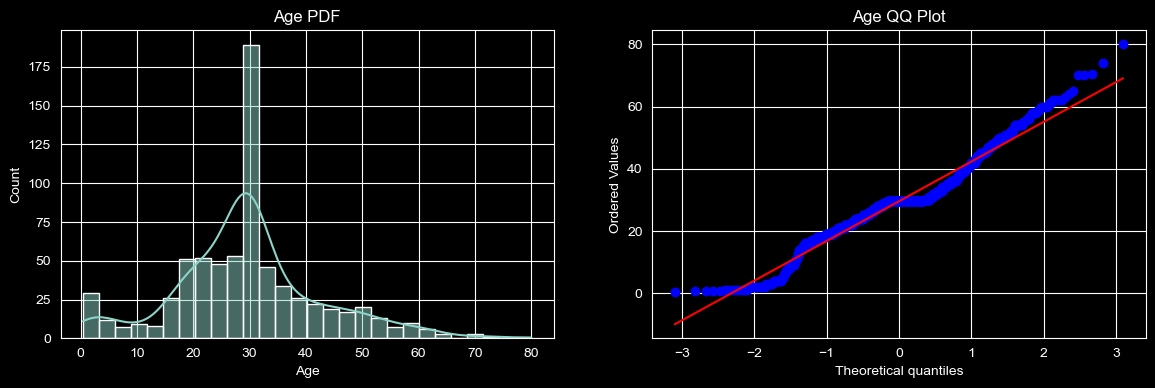

In [35]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train["Age"], kde = True)
plt.title("Age PDF")

plt.subplot(122)
stats.probplot(X_train["Age"], dist="norm", plot=plt)
plt.title("Age QQ Plot")

plt.show()

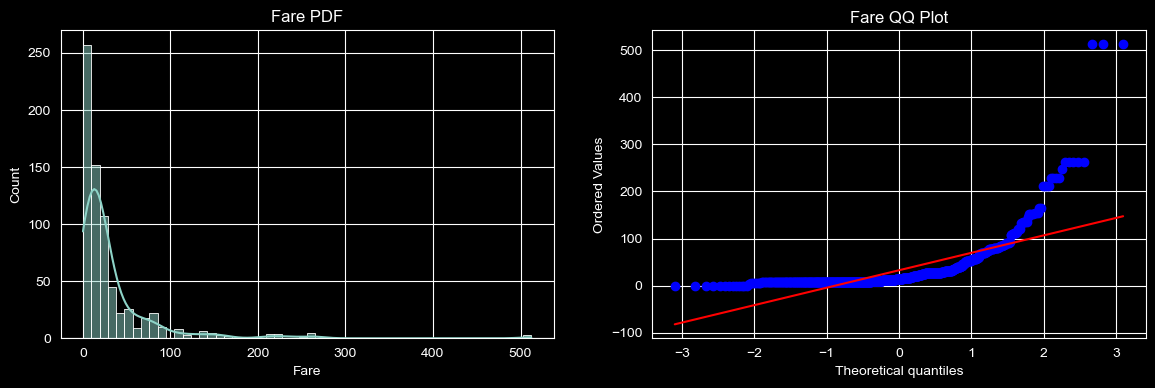

In [36]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train["Fare"], kde = True)
plt.title("Fare PDF")

plt.subplot(122)
stats.probplot(X_train["Fare"], dist="norm", plot=plt)
plt.title("Fare QQ Plot")

plt.show()

In [49]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [50]:
clf.fit(X_train, y_train)
clf2.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("Accuracy LR: ", accuracy_score(y_test, y_pred))
print("Accuracy DT: ", accuracy_score(y_test, y_pred1))

Accuracy LR:  0.6480446927374302
Accuracy DT:  0.6703910614525139


In [51]:
trf = FunctionTransformer(func=np.log1p)

In [52]:
X_train_transform = trf.fit_transform(X_train)
X_test_transform = trf.transform(X_test)

In [53]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transform, y_train)
clf2.fit(X_train_transform, y_train)

y_pred = clf.predict(X_test_transform)
y_pred1 = clf2.predict(X_test_transform)

print("Accuracy LR: ", accuracy_score(y_test, y_pred))
print("Accuracy DT: ", accuracy_score(y_test, y_pred1))

Accuracy LR:  0.6815642458100558
Accuracy DT:  0.664804469273743


In [57]:
X_transformed = trf.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6566416978776529


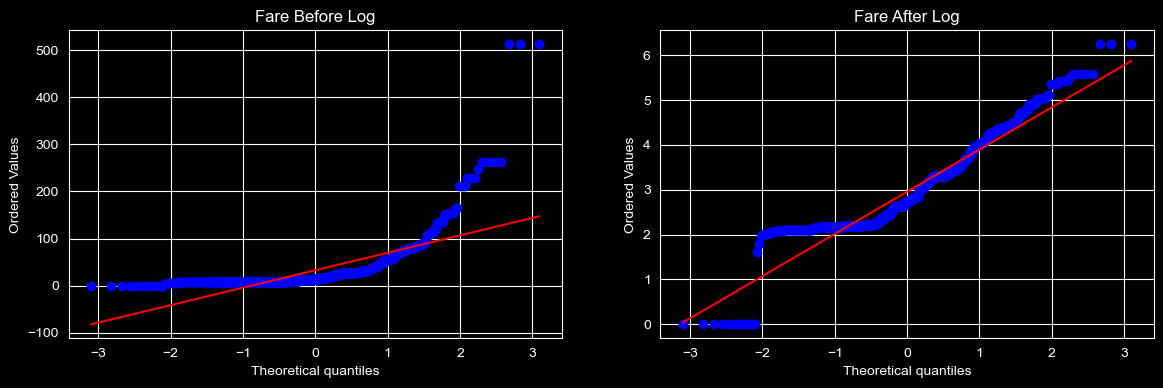

In [59]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transform['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()

Text(0.5, 1.0, 'Age After Log')

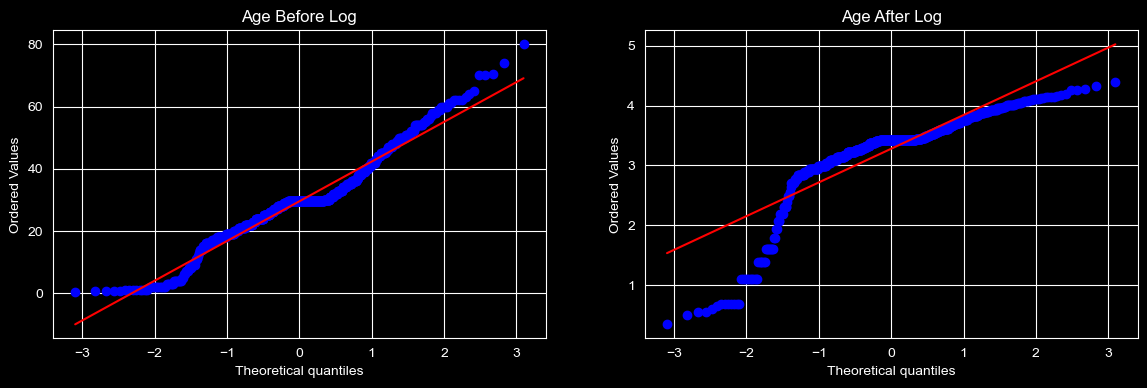

In [60]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transform['Age'], dist="norm", plot=plt)
plt.title('Age After Log')


In [62]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [63]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.6759776536312849


In [64]:
X_transformed2 = trf2.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6610861423220973


In [65]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]

    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')

    X_trans = trf.fit_transform(X)

    clf = LogisticRegression()

    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy 0.6712609238451936


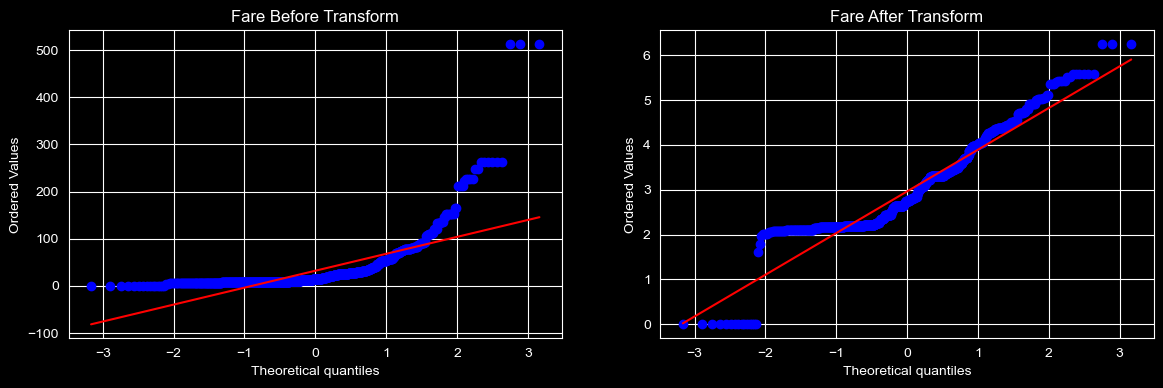

In [67]:
apply_transform(np.log1p)